In [3]:
import numpy as np
a = np.array([1,2,3])
print(a)

[1 2 3]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
A = np.array([
    [-1,3],
    [3,2]],
    dtype = np.dtype(float))

B = np.array([7,1], dtype=np.dtype(float))

print("Matrix A:" , A)
print("Matrix B:" , B)

Matrix A: [[-1.  3.]
 [ 3.  2.]]
Matrix B: [7. 1.]


In [6]:
print("Shape of A:", np.shape(A))
print("Shape of B: ",np.shape(B))

Shape of A: (2, 2)
Shape of B:  (2,)


In [8]:
print("Solution:", np.linalg.solve(A,B))

Solution: [-1.  2.]


In [12]:
print("Determinent of A:" , np.linalg.det(A))
# print("Determinent of B:" , np.linalg.det(B)) as one one dimension

Determinent of A: -11.000000000000002


In [25]:
try: 
    x = np.linalg.solve(A,B)
    print("Solution:")
    print(x)
except np.linalg.LinAlgError as err:
    print(err)

Singular matrix


In [11]:
A_system = np.hstack((A,B.reshape((2,1))))
print(A_system)

[[-1.  3.  7.]
 [ 3.  2.  1.]]


In [ ]:
import numpy as np
 
def plot_lines(M):
    x_1 = np.linspace(-10, 10, 100)
    x_2_line_1 = (M[0,2] - M[0,0] * x_1) / M[0,1] # x2 = c -ax1 / b 1st row
    x_2_line_2 = (M[1,2] - M[1,0] * x_1) / M[1,1] 
    _, ax = plt.subplots(figsize=(10, 10))
    ax.plot(x_1, x_2_line_1, '-', linewidth=2, color='#0075ff',
            label=f'$x_2={-M[0,0]/M[0,1]:.2f}x_1 + {M[0,2]/M[0,1]:.2f}$') # slope and intercapt
    ax.plot(x_1, x_2_line_2, '-', linewidth=2, color='#ff7300',
            label=f'$x_2={-M[1,0]/M[1,1]:.2f}x_1 + {M[1,2]/M[1,1]:.2f}$') # -a/b and c/b
 
    A = M[:, 0:-1] # take every row and every column except the last one.
    b = M[:, -1::].flatten() # extract the final coloumn
    d = np.linalg.det(A) 
 
    if d != 0: # explain if solution is unique
        solution = np.linalg.solve(A, b) # solves solution
        ax.plot(solution[0], solution[1], '-o', mfc='none',
                markersize=10, markeredgecolor='#ff0000', markeredgewidth=2)
        ax.text(solution[0]-0.25, solution[1]+0.75, f'$({solution[0]:.0f}, {solution[1]:.0f})$', fontsize=14)
 
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(np.arange(-10, 10))
    ax.set_yticks(np.arange(-10, 10))
 
    plt.xlabel('$x_1$', size=14)
    plt.ylabel('$x_2$', size=14)
    plt.legend(loc='upper right', fontsize=14)
    plt.axis([-10, 10, -10, 10])
 
    plt.grid()
    plt.gca().set_aspect("equal")
    plt.show()

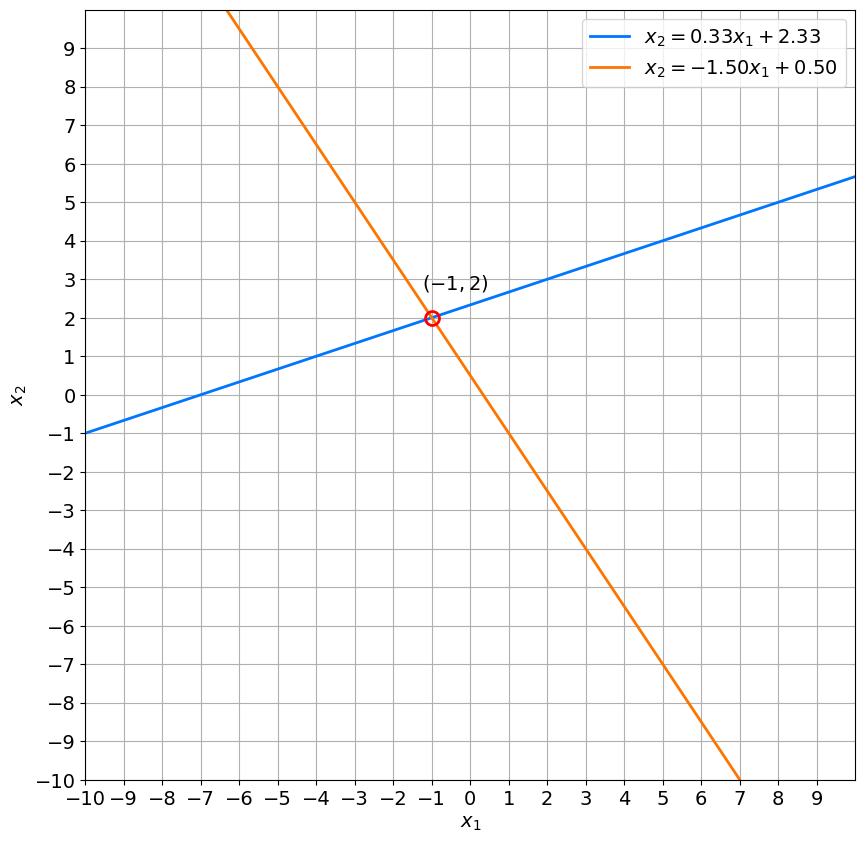

None


In [17]:
print(plot_lines(A_system))

[[-1.  3.  7.]
 [ 3.  2.  1.]]
Determinent of A: 0.0
Linear Algebra Error: Singular matrix


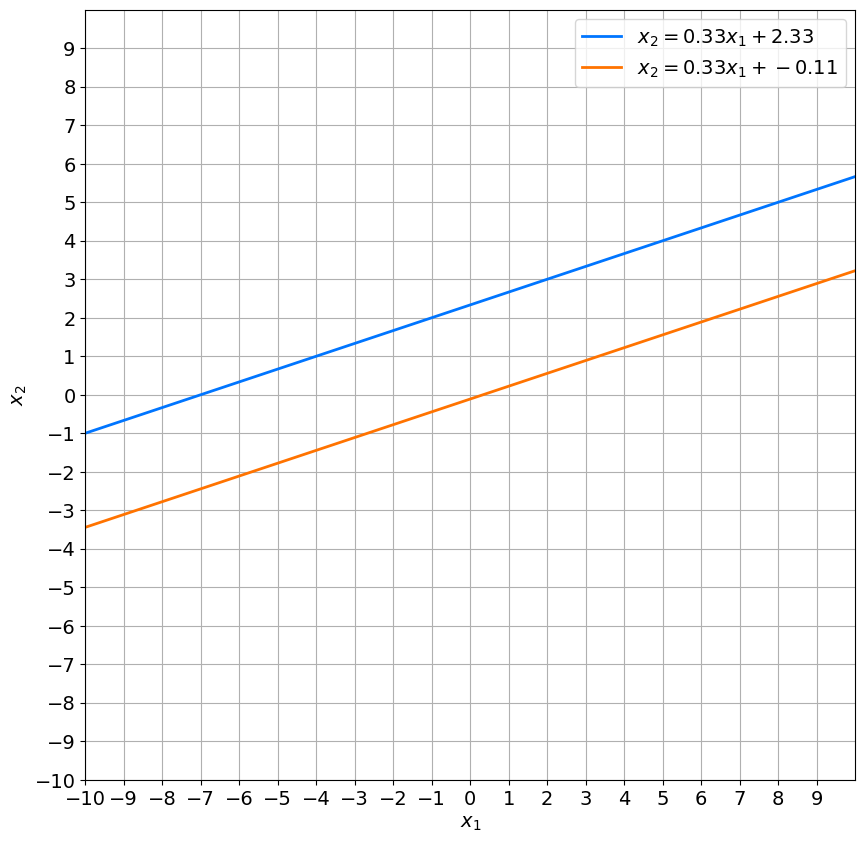

None


In [ ]:
# -x1 + 3x2 = 7
# 3x1 -9x2 =1

A = np.array([
    [-1,3],
    [3,-9]],
    dtype = np.dtype(float))

B = np.array([7,1], dtype=np.dtype(float))

B_system = np.hstack((A,B.reshape((2,1))))
print(A_system)
print("Determinent of A:" , np.linalg.det(A))
'''
try: 
    x = np.linalg.solve(A,B)
    print("Solution:")         # when no unique solution has been reached the code 
    print(x)                     usually stops the try except prevents that
except np.linalg.linialderror as err:
    print(err)
'''
try:
  x = np.linalg.solve(A, B)
  print("Solution:")
  print(x)
except np.linalg.LinAlgError as err:
  print("Linear Algebra Error:", err)
print(plot_lines(B_system))

[[-1.  3.  7.]
 [ 3.  2.  1.]]
Determinent of A: 0.0
Linear Algebra Error: Singular matrix


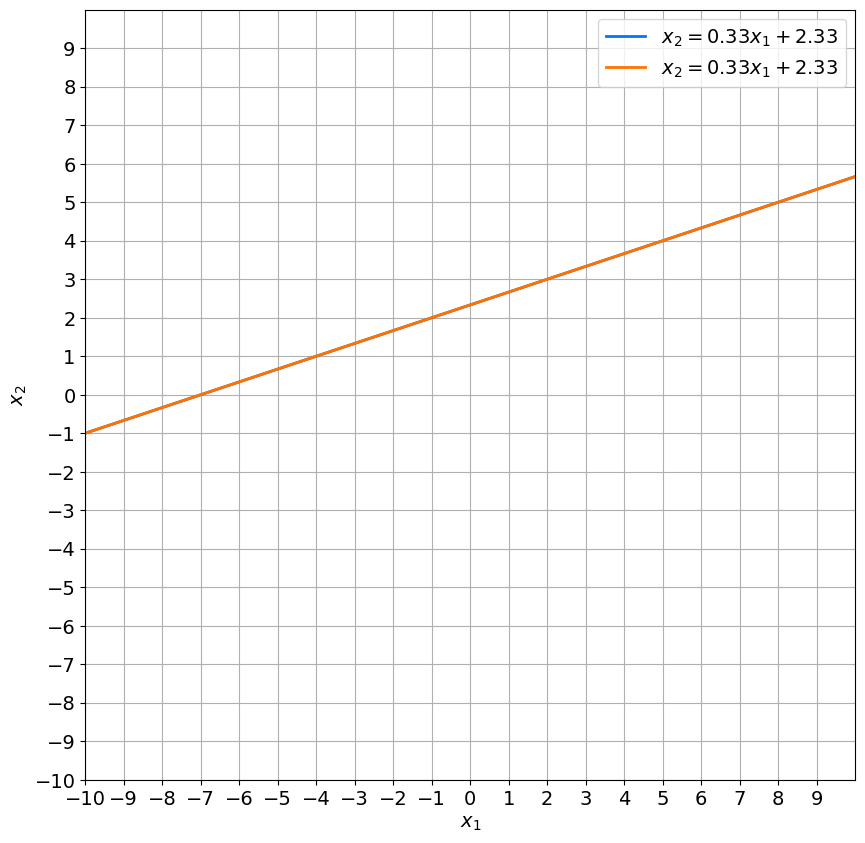

None


In [24]:

A = np.array([
    [-1,3],
    [3,-9]],
    dtype = np.dtype(float))

B = np.array([7,-21], dtype=np.dtype(float))

B_system = np.hstack((A,B.reshape((2,1))))
print(A_system)
print("Determinent of A:" , np.linalg.det(A))
'''
try: 
    x = np.linalg.solve(A,B)
    print("Solution:")                     <-This does work as linialderror will give a name error, doesnt even exists
    print(x)
except np.linalg.linialderror as err:
    print(err)
'''
try:
  x = np.linalg.solve(A, B)
  print("Solution:")
  print(x)
except np.linalg.LinAlgError as err:
  print("Linear Algebra Error:", err)
print(plot_lines(B_system))

In [6]:
import time
A = np.random.rand(1000000)
B = np.random.rand(1000000)
tic = time.time()
c = np.dot(A,B)
toc = time.time()
time_taken = 1000*(toc-tic)
print(time_taken)

15.652656555175781


In [8]:
c = 0
tic = time.time()
for i in range(1000000):
    c+=A[i]*B[i]
toc = time.time()
print(c)
time_taken = 1000*(toc-tic)
print(time_taken)

249899.24125136842
1276.825189590454


In [10]:
# Broadcasting, Vertical sum of vector
A = np.array([[2,3,5],[7,2,1],[4,5,1]])
print(A)
cal = A.sum(axis=0) # axis 0 =sum vertically
print(cal)

# convert to percentage
per = 100*(A/cal.reshape(1,3))
print(per)

[[2 3 5]
 [7 2 1]
 [4 5 1]]
[13 10  7]
[[15.38461538 30.         71.42857143]
 [53.84615385 20.         14.28571429]
 [30.76923077 50.         14.28571429]]


In [11]:
# Broadcasting, horizontal sum of vector
A = np.array([[2,3,5],[7,2,1],[4,5,1]])
print(A)
cal = A.sum(axis=1) # axis 1 =sum vhorizontal
print(cal)

# convert to percentage
per = 100*(A/cal.reshape(1,3))
print(per)

[[2 3 5]
 [7 2 1]
 [4 5 1]]
[10 10 10]
[[20. 30. 50.]
 [70. 20. 10.]
 [40. 50. 10.]]


In [12]:
# multiply with scalar
B = np.array([2,3,4])
print(B)
c = B*100
print(c)

[2 3 4]
[200 300 400]


In [13]:
# add constant number in vector
B = np.array([2,3,4])
print(B)
c = B + 100
print(c)

[2 3 4]
[102 103 104]


In [15]:
# add two vector
A = np.array([[1,2,3],[1,2,3],[1,2,3]])
B = np.array([2,3,4])
print(A,B)
C = A + B
print(C)

[[1 2 3]
 [1 2 3]
 [1 2 3]] [2 3 4]
[[3 5 7]
 [3 5 7]
 [3 5 7]]


In [18]:
# Problems in rank 1 array, always convey from 1D to 2D
A = np.random.rand(5)
print(A, A.shape)
print(np.dot(A,A.T)) # transpose

B = np.random.rand(5,1)
print(B)
print(np.dot(B,B.T))

[0.84878256 0.24507099 0.0324753  0.20338792 0.0011294 ] (5,)
0.8229141841811112
[[0.35157288]
 [0.85308953]
 [0.38931896]
 [0.53770583]
 [0.68426847]]
[[0.12360349 0.29992315 0.13687399 0.18904279 0.24057024]
 [0.29992315 0.72776174 0.33212393 0.45871121 0.58374227]
 [0.13687399 0.33212393 0.15156925 0.20933908 0.26639869]
 [0.18904279 0.45871121 0.20933908 0.28912756 0.36793515]
 [0.24057024 0.58374227 0.26639869 0.36793515 0.46822334]]


In [20]:
# Element wise multiplication
# normailzation of vector is converting a vector with same direction same but unit 1
# differnece in dot product in ML and neural network, dimension change?
# Singular is non-unique, determinant 0 
#Experiment-1  Try with different shape (4,5)*(4,1),
#(4,5)*(1,4),  (4,2)*(2,2) and so on.

import numpy as np
 
# Case 1: (4,5) * (4,1)
A = np.random.randint(1, 10, (np.random.randint(1, 10),np.random.randint(1, 10)))
B = np.random.randint(1, 10, (np.random.randint(1, 10),np.random.randint(1, 10)))


print("Shape of A:", A.shape)
print("Shape of B:", B.shape)
 
try:
    C = np.matmul(A, B)
    print("Result Shape:", C.shape)
except ValueError as e:
    print("Error:", e)
 
# Case 2: (4,5) * (1,4)
A = np.random.randint(1, 10, (4,5))
B = np.random.randint(1, 10, (1,4))
 
print("\nShape of A:", A.shape)
print("Shape of B:", B.shape)
 
try:
    C = np.matmul(A, B)
    print("Result Shape:", C.shape)
except ValueError as e:
    print("Error:", e)
 
# Case 3: (4,2) * (2,2)
A = np.random.randint(1, 10, (4,2))
B = np.random.randint(1, 10, (2,2))
 
print("\nShape of A:", A.shape)
print("Shape of B:", B.shape)
 
C = np.matmul(A, B)
print("Result Shape:", C.shape)
print("Result:\n", C)

Shape of A: (7, 5)
Shape of B: (8, 9)
Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 8 is different from 5)

Shape of A: (4, 5)
Shape of B: (1, 4)
Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 5)

Shape of A: (4, 2)
Shape of B: (2, 2)
Result Shape: (4, 2)
Result:
 [[98 68]
 [77 60]
 [70 58]
 [35 24]]
